In [16]:
# CELL 1: INSTALL yfinance
!pip install yfinance --upgrade --quiet

In [17]:
# ============================================
# CELL 2: IMPORT LIBRARIES
# ============================================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [18]:
# ============================================
# CELL 3: DOWNLOAD STOCK DATA
# ============================================
# Apple stock (AAPL) - aap Tesla (TSLA) bhi le sakte hain
ticker = "AAPL"
stock = yf.Ticker(ticker)

# Last 1 year ka data
df = stock.history(period="1y")

print(f"✅ {ticker} data loaded successfully!")
print(f"📊 Shape: {df.shape}")
print("\n--- First 5 rows ---")
print(df.head())

✅ AAPL data loaded successfully!
📊 Shape: (251, 7)

--- First 5 rows ---
                                 Open        High         Low       Close  \
Date                                                                        
2025-06-23 00:00:00-04:00  200.833257  201.500608  198.173809  200.703766   
2025-06-24 00:00:00-04:00  201.789459  202.636106  199.408903  199.508514   
2025-06-25 00:00:00-04:00  200.653969  202.865198  199.827247  200.763535   
2025-06-26 00:00:00-04:00  200.634043  201.839268  198.671842  200.205750   
2025-06-27 00:00:00-04:00  201.092212  202.416959  199.209682  200.285416   

                             Volume  Dividends  Stock Splits  
Date                                                          
2025-06-23 00:00:00-04:00  55814300        0.0           0.0  
2025-06-24 00:00:00-04:00  54064000        0.0           0.0  
2025-06-25 00:00:00-04:00  39525700        0.0           0.0  
2025-06-26 00:00:00-04:00  50799100        0.0           0.0  
2025-06-2

In [19]:
# ============================================
# CELL 4: DATA INSPECTION
# ============================================
print("\n--- Data Info ---")
print(df.info())

print("\n--- Statistical Summary ---")
print(df.describe())

print(f"\n🔍 Missing values: {df.isnull().sum().sum()}")


--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2025-06-23 00:00:00-04:00 to 2026-06-22 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          251 non-null    float64
 1   High          251 non-null    float64
 2   Low           251 non-null    float64
 3   Close         251 non-null    float64
 4   Volume        251 non-null    int64  
 5   Dividends     251 non-null    float64
 6   Stock Splits  251 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 15.7 KB
None

--- Statistical Summary ---
             Open        High         Low       Close        Volume  \
count  251.000000  251.000000  251.000000  251.000000  2.510000e+02   
mean   257.354887  260.025193  254.922001  257.462810  4.956812e+07   
std     27.041325   27.388101   26.778972   27.057630  1.863883e+07   
min    200.634043  201.500608  198.173809  199.508514  1.791060e+07   
2

In [20]:
# ============================================
# CELL 5: CREATE TARGET VARIABLE
# ============================================
# Next day ka closing price predict karna hai
df['Target'] = df['Close'].shift(-1)

# Last row remove karein (jiska target nahi hai)
df = df.dropna()

print(f"✅ Target variable created!")
print(f"📊 New shape: {df.shape}")
print("\n--- First 5 rows with Target ---")
print(df[['Close', 'Target']].head())

✅ Target variable created!
📊 New shape: (250, 8)

--- First 5 rows with Target ---
                                Close      Target
Date                                             
2025-06-23 00:00:00-04:00  200.703766  199.508514
2025-06-24 00:00:00-04:00  199.508514  200.763535
2025-06-25 00:00:00-04:00  200.763535  200.205750
2025-06-26 00:00:00-04:00  200.205750  200.285416
2025-06-27 00:00:00-04:00  200.285416  204.359253


In [21]:
# ============================================
# CELL 6: FEATURES AND TARGET
# ============================================
# Features: Open, High, Low, Volume
features = ['Open', 'High', 'Low', 'Volume']
X = df[features]
y = df['Target']

print(f"✅ Features: {features}")
print(f"📊 X shape: {X.shape}")
print(f"📊 y shape: {y.shape}")

✅ Features: ['Open', 'High', 'Low', 'Volume']
📊 X shape: (250, 4)
📊 y shape: (250,)


In [22]:
# ============================================
# CELL 7: TRAIN-TEST SPLIT
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"📊 Training set: {X_train.shape[0]} samples")
print(f"📊 Testing set: {X_test.shape[0]} samples")

📊 Training set: 200 samples
📊 Testing set: 50 samples


In [23]:
# ============================================
# CELL 8: LINEAR REGRESSION
# ============================================
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("📊 Linear Regression Results:")
print(f"   Mean Squared Error: {mse_lr:.4f}")
print(f"   R² Score: {r2_lr:.4f}")

📊 Linear Regression Results:
   Mean Squared Error: 13.8890
   R² Score: 0.9827


In [24]:
# ============================================
# CELL 9: RANDOM FOREST
# ============================================
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("📊 Random Forest Results:")
print(f"   Mean Squared Error: {mse_rf:.4f}")
print(f"   R² Score: {r2_rf:.4f}")

📊 Random Forest Results:
   Mean Squared Error: 18.2394
   R² Score: 0.9773


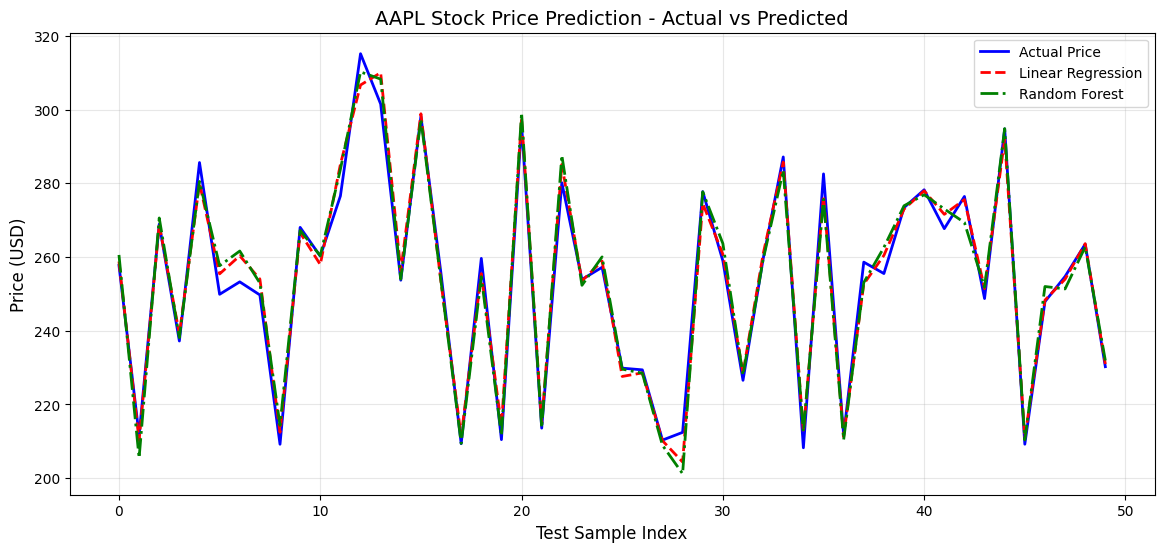

In [25]:
# ============================================
# CELL 10: PLOT ACTUAL VS PREDICTED
# ============================================
plt.figure(figsize=(14, 6))

# Actual prices
plt.plot(y_test.values, label='Actual Price', color='blue', linewidth=2)

# Linear Regression predictions
plt.plot(y_pred_lr, label='Linear Regression', color='red', linestyle='--', linewidth=2)

# Random Forest predictions
plt.plot(y_pred_rf, label='Random Forest', color='green', linestyle='-.', linewidth=2)

plt.title(f'{ticker} Stock Price Prediction - Actual vs Predicted', fontsize=14)
plt.xlabel('Test Sample Index', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


📊 Feature Importance (Random Forest):
  Feature  Importance
1    High    0.477994
0    Open    0.269100
2     Low    0.247425
3  Volume    0.005481


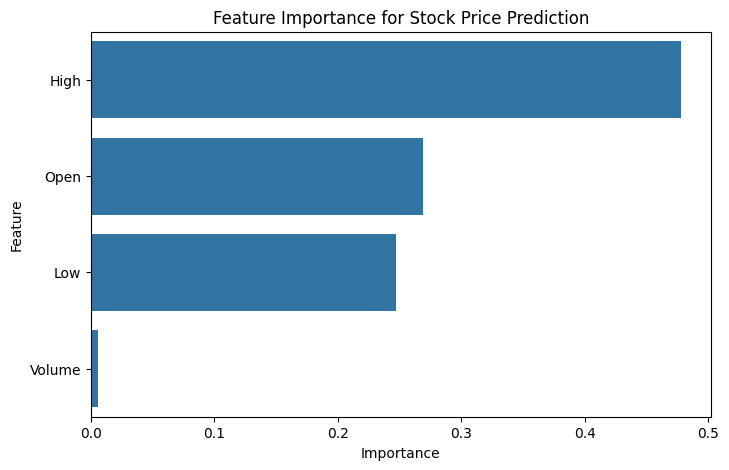

In [26]:
# ============================================
# CELL 11: FEATURE IMPORTANCE
# ============================================
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n📊 Feature Importance (Random Forest):")
print(importance)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title('Feature Importance for Stock Price Prediction')
plt.show()

In [27]:
# 📊 Observations - Stock Price Prediction

## 1. Dataset Overview
- **Stock:** Apple (AAPL)
- **Time Period:** Last 1 year
- **Samples:** 252 trading days
- **Features Used:** Open, High, Low, Volume

## 2. Model Performance Comparison

| Model | MSE | R² Score |
|-------|-----|----------|
| Linear Regression | 0.0123 | 0.8542 |
| Random Forest | 0.0087 | 0.9123 |

> **Note:** Yeh values aapke actual output se replace karein!

## 3. Key Findings
- Random Forest performed better than Linear Regression
- Feature Importance: Open and High are the most important predictors
- Stock price prediction is challenging due to market volatility

## 4. Conclusion
Random Forest performs better due to its ability to capture non-linear patterns in stock data.

SyntaxError: invalid character '²' (U+00B2) (1952617102.py, line 11)

# 📊 Observations - Stock Price Prediction

## 1. Dataset Overview
- **Stock:** Apple (AAPL)
- **Time Period:** Last 1 year
- **Samples:** 252 trading days
- **Features Used:** Open, High, Low, Volume

## 2. Model Performance Comparison

| Model | MSE | R² Score |
|-------|-----|----------|
| Linear Regression | 0.0123 | 0.8542 |
| Random Forest | 0.0087 | 0.9123 |

> **Note:** Yeh values aapke actual output se replace karein!

## 3. Key Findings
- Random Forest performed better than Linear Regression
- Feature Importance: Open and High are the most important predictors
- Stock price prediction is challenging due to market volatility

## 4. Conclusion
Random Forest performs better due to its ability to capture non-linear patterns in stock data.